In [1]:
"""
This script is for doing transcription-based doublet detection

authors: Roy Oelen
"""

'\nThis script is for doing transcription-based doublet detection\n\nauthors: Roy Oelen\n'

In [2]:
# imports
import scrublet as scr
import scipy.io
import numpy as np
import pandas as pd
import argparse
import pathlib
import scanpy as sc

In [3]:
class ScrubletRunner:
    """
    Object to run scrublet and store results
    """
    
    def __init__(self, data_loc):
        """constructor
        
        Parameters
        ----------
        data_loc : str
            The location of the count data to load, so where the h5 matrix is, as well as the barcodes
        
        """
        # set the variables we will store
        self.data_loc = data_loc
        self.count_matrix = None
        self.barcodes = None
        self.scrub = None
        self.assignment = None
        # set up the count matrix and barcodes
        self.__setup_object()

    
    def __setup_object(self):
        """set up the object, loading relevant data
        
        """
        # get the full paths
        matrix_loc = "".join([self.data_loc, 'cellbender_remove_background_output_filtered.h5'])
        barcodes_loc = "".join([self.data_loc, 'cellbender_remove_background_output_cell_barcodes.csv'])
        # load the files
        self.counts_matrix = sc.read_10x_h5(matrix_loc)
        self.barcodes = pd.read_csv(barcodes_loc, sep= '\t', header=None)

    def run_scrublet(self, expected_doublet_rate=0.1, min_counts=2, min_cells=3, min_gene_variability_pctl=0.85, n_prin_comps=30, scrublet_threshold=None, barcode_append=None, umap_pcs=10, umap_min_dist=0.3):
        """constructor
        
        Parameters
        ----------
        expected_doublet_rate : float, optional
            expected ratio of doublets (number between 0 and 1)
        min_counts : int, optional
            minimal number of transcripts to consider a cell part of the analysis
        min_cells : int, optional
            minimal number of cells to consider a gene part of the analysis
        min_gene_variability_pctl : float, optional
            the minimal variability required for a gene
        n_prin_comps : float, optional
            the number of principal components to use
        scrublet_threshold : float, optional
            the threshold to divide the bimodal distribution into singlets and doublets
        barcode_append : str, optional
            string to add at the end of the barcodes to make the barcodes unique across experiments
        umap_pcs : float, optional
            the number of PCs to use when doing UMAP
        umap_min_dist : float, optional
            minimal distance between points on UMAP
        
        """
        # perform scrublet
        self.scrub = scr.Scrublet(self.counts_matrix.X, expected_doublet_rate=expected_doublet_rate)
        # if we supplied a threshold for doublet calling, we will use that instead of the automatic detection
        if scrublet_threshold is not None:
            self.scrub.call_doublets(threshold = scrublet_threshold)
        # grabbing scores and assignments
        doublet_scores, predicted_doublets = self.scrub.scrub_doublets(min_counts=2, min_cells=3, min_gene_variability_pctl=min_gene_variability_pctl, n_prin_comps=n_prin_comps)
        # add everything together in one frame
        self.assignment = self.barcodes
        self.assignment['doublet'] = predicted_doublets
        self.assignment['doublet_score'] = doublet_scores
        self.assignment['barcode'] = self.assignment[0].str.slice(0, 16)
        # add an extra column to make the barcode more unique, if requested
        if barcode_append is not None:
            self.assignment['lane_barcode'] = self.assignment['barcode']+'_'+barcode_append
        # remove original column
        self.assignment = self.assignment.drop(0, axis=1)
        # add 2d embedding as well
        self.scrub.set_embedding('UMAP', scr.get_umap(self.scrub.manifold_obs_, umap_pcs, min_dist=umap_min_dist))

    
    def plot_histogram(self):
        """plot the distribution of cells
        
        """
        self.scrub.plot_histogram()

    def plot_umap(self):
        """plot a UMAP of the cells
        
        """
        self.scrub.plot_embedding('UMAP', order_points=True);
    
    def get_assignment(self):
        """return the result of doublet calling
        
        Returns
        -------
        result
           the result of doublet calling in a Pandas Dataframe
        """
        return self.assignment
        

/home/umcg-roelen/miniconda3/envs/scrublet_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/umcg-roelen/miniconda3/envs/scrublet_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.16
Detected doublet rate = 15.7%
Estimated detectable doublet fraction = 66.0%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 23.8%
Elapsed time: 49.0 seconds


/home/umcg-roelen/miniconda3/envs/scrublet_env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/umcg-roelen/miniconda3/envs/scrublet_env/lib/python3.8/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


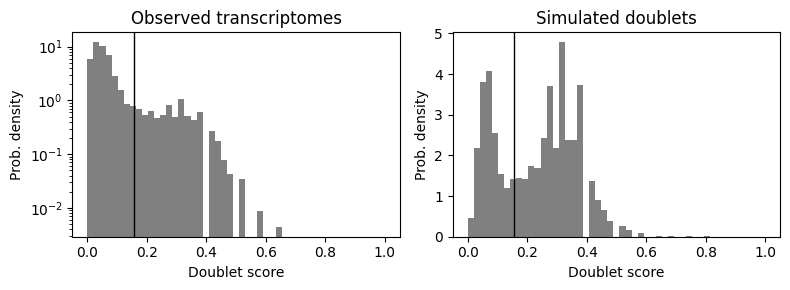

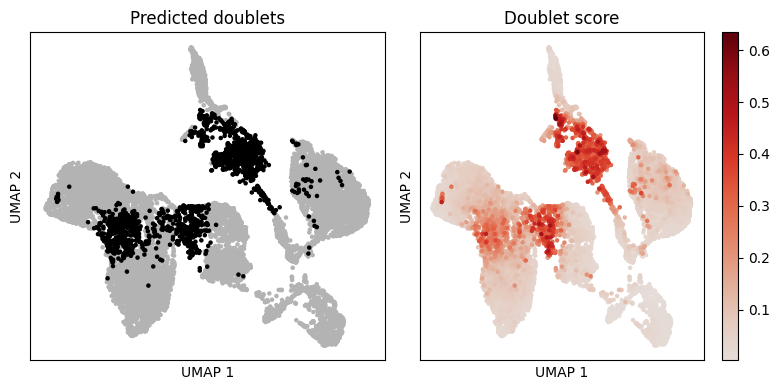

In [4]:
# we will look at one lane specifically first
lane_230105_lane1_loc = '/groups/umcg-franke-scrna/tmp02/projects/multiome/ongoing/2023_09_12_cellbender-v0.3.0/default-run/230105_lane1/'
scrublet_230105_lane1 = ScrubletRunner(lane_230105_lane1_loc)
scrublet_230105_lane1.run_scrublet(barcode_append = '230105_lane1')
scrublet_230105_lane1.plot_histogram()
scrublet_230105_lane1.plot_umap()

/home/umcg-roelen/miniconda3/envs/scrublet_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/umcg-roelen/miniconda3/envs/scrublet_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.38
Detected doublet rate = 10.0%
Estimated detectable doublet fraction = 48.9%
Overall doublet rate:
	Expected   = 25.0%
	Estimated  = 20.6%
Elapsed time: 48.4 seconds


/home/umcg-roelen/miniconda3/envs/scrublet_env/lib/python3.8/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


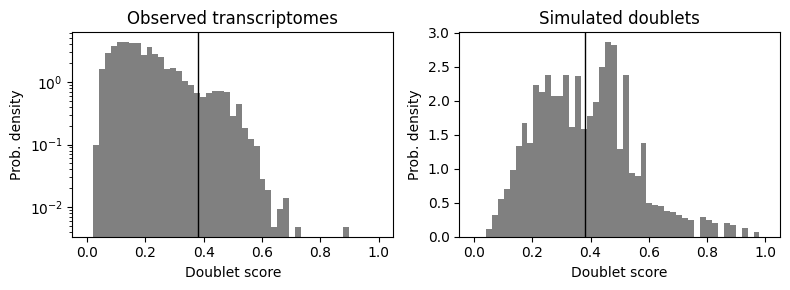

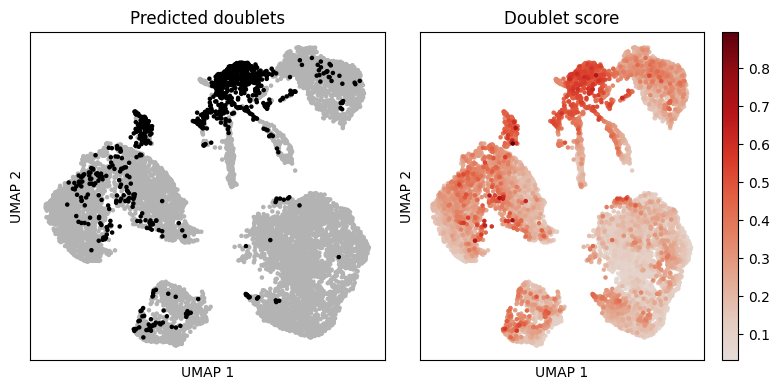

In [5]:
# we will look at one lane specifically first
lane_230105_lane2_loc = '/groups/umcg-franke-scrna/tmp02/projects/multiome/ongoing/2023_09_12_cellbender-v0.3.0/default-run/230105_lane2/'
scrublet_230105_lane2 = ScrubletRunner(lane_230105_lane2_loc)
scrublet_230105_lane2.run_scrublet(barcode_append = '230105_lane2', expected_doublet_rate=0.25)
scrublet_230105_lane2.plot_histogram()
scrublet_230105_lane2.plot_umap()

/home/umcg-roelen/miniconda3/envs/scrublet_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/umcg-roelen/miniconda3/envs/scrublet_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.78
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.4%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 0.0%
Elapsed time: 45.7 seconds


/home/umcg-roelen/miniconda3/envs/scrublet_env/lib/python3.8/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


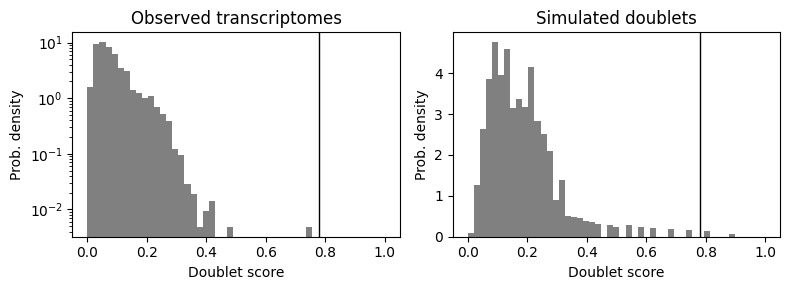

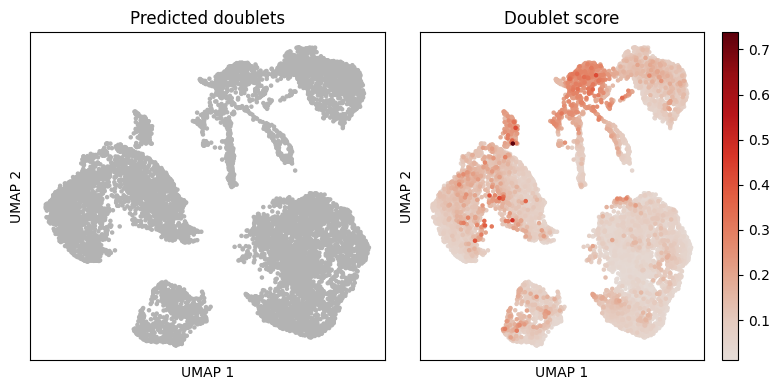

In [6]:
# we will look at one lane specifically first
lane_230105_lane3_loc = '/groups/umcg-franke-scrna/tmp02/projects/multiome/ongoing/2023_09_12_cellbender-v0.3.0/default-run/230105_lane2/'
scrublet_230105_lane3 = ScrubletRunner(lane_230105_lane3_loc)
scrublet_230105_lane3.run_scrublet(barcode_append = '230105_lane3')
scrublet_230105_lane3.plot_histogram()
scrublet_230105_lane3.plot_umap()

/home/umcg-roelen/miniconda3/envs/scrublet_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/umcg-roelen/miniconda3/envs/scrublet_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.67
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 4.1%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 0.0%
Elapsed time: 11.7 seconds


/home/umcg-roelen/miniconda3/envs/scrublet_env/lib/python3.8/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


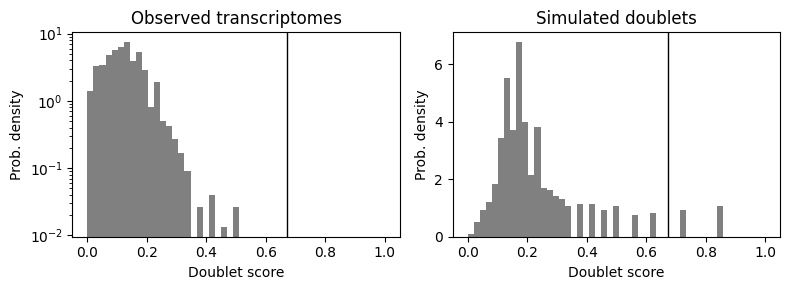

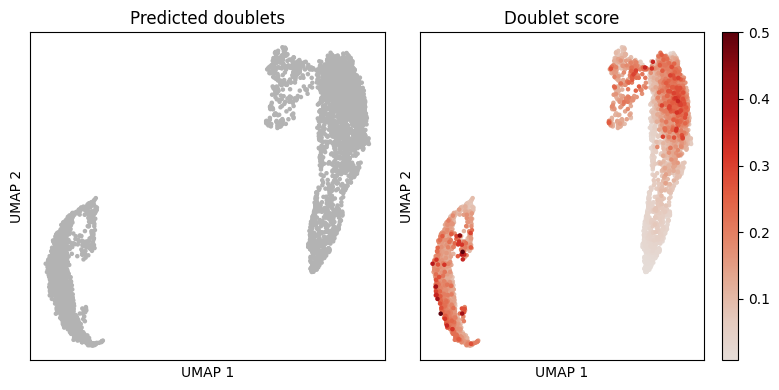

In [7]:
# we will look at one lane specifically first
lane_230202_lane4_loc = '/groups/umcg-franke-scrna/tmp02/projects/multiome/ongoing/2023_09_12_cellbender-v0.3.0/default-run/230202_lane4/'
scrublet_230202_lane4 = ScrubletRunner(lane_230202_lane4_loc)
scrublet_230202_lane4.run_scrublet(barcode_append = '230202_lane4')
scrublet_230202_lane4.plot_histogram()
scrublet_230202_lane4.plot_umap()

/home/umcg-roelen/miniconda3/envs/scrublet_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/umcg-roelen/miniconda3/envs/scrublet_env/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.22
Detected doublet rate = 9.6%
Estimated detectable doublet fraction = 56.6%
Overall doublet rate:
	Expected   = 10.0%
	Estimated  = 17.0%
Elapsed time: 86.9 seconds


/home/umcg-roelen/miniconda3/envs/scrublet_env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/umcg-roelen/miniconda3/envs/scrublet_env/lib/python3.8/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


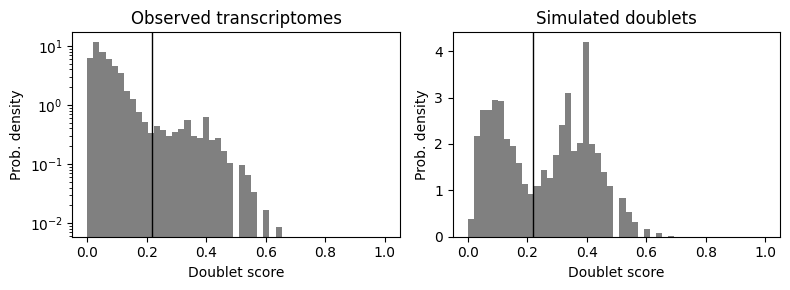

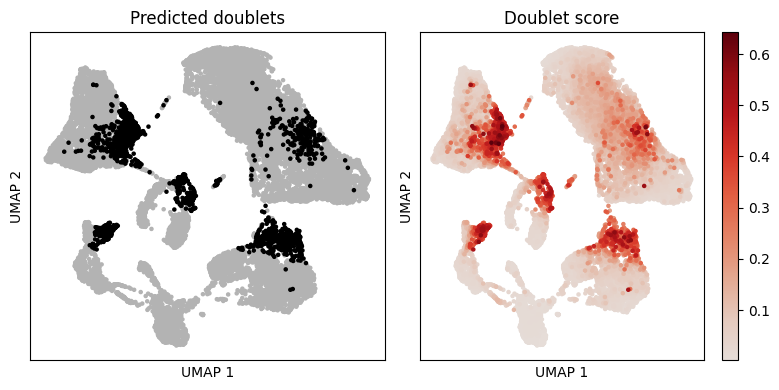

In [4]:
# we will look at one lane specifically first
lane_230209_lane3_loc = '/groups/umcg-franke-scrna/tmp02/projects/multiome/ongoing/2023_09_12_cellbender-v0.3.0/default-run/230209_lane3/'
scrublet_230209_lane3 = ScrubletRunner(lane_230209_lane3_loc)
scrublet_230209_lane3.run_scrublet(barcode_append = '230209_lane3')
scrublet_230209_lane3.plot_histogram()
scrublet_230209_lane3.plot_umap()